In [ ]:
!pip -q install sdv xgboost scipy scikit-learn imbalanced-learn

from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier

from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer, CTGANSynthesizer



# PATHS / SETTINGS

ORIGINAL_INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
MCAR_DIR = "/content/drive/MyDrive/research/MCAR_DATASETS"
OUTDIR = "/content/drive/MyDrive/research/CTGAN_TVAE_IMPUTE_RESULTS"

TARGET_COL = "final_result"
RANDOM_SEED = 42

# columns to drop from ML downstream evaluation
DROP_FOR_ML = ["final_result", "id_student", "code_module", "code_presentation"]


IMPUTE_COLS = [f"V_{i}" for i in range(1, 11)]

os.makedirs(OUTDIR, exist_ok=True)
np.random.seed(RANDOM_SEED)



# HELPERS

def safe_numeric_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def prepare_xgb_xy(df_in: pd.DataFrame):
    X = df_in.drop(columns=[c for c in DROP_FOR_ML if c in df_in.columns], errors="ignore")
    X = X.select_dtypes(include=[np.number]).copy()
    y = df_in[TARGET_COL].astype(int).copy()
    return X, y

def eval_xgb_f1(df_in: pd.DataFrame, seed=42):
    """
    Same downstream style for all methods:
    - fixed 80/20 split
    - 5-fold CV inside training split
    - report cv mean/std and test F1
    """
    X, y = prepare_xgb_xy(df_in)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        eval_metric="logloss",
        n_jobs=-1,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "cv_f1_mean": float(np.mean(cv_scores)),
        "cv_f1_std": float(np.std(cv_scores)),
        "test_f1": float(f1_score(y_test, y_pred)),
    }

def sdv_train_fill(df_in: pd.DataFrame) -> pd.DataFrame:
    """
    SDV CTGAN/TVAE cannot train with NaNs.
    Train on COMPLETE original training data.
    """
    df = df_in.copy()
    for c in df.columns:
        if c == TARGET_COL:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].fillna(df[c].mean())
        else:
            mode = df[c].mode(dropna=True)
            df[c] = df[c].fillna(mode.iloc[0] if len(mode) else "UNK")
    return df

def run_tvae_ctgan(df_train_full: pd.DataFrame):
    """
    Train once on the original complete training split.
    """
    df_train = sdv_train_fill(df_train_full)

    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_train)

    tvae = TVAESynthesizer(
        metadata=metadata,
        epochs=300,
        batch_size=128,
        cuda=False
    )
    tvae.fit(df_train)
    print("TVAE trained.")

    ctgan = CTGANSynthesizer(
        metadata=metadata,
        epochs=300,
        batch_size=128,
        pac=1,
        cuda=False
    )
    ctgan.fit(df_train)
    print("CTGAN trained.")

    return tvae, ctgan

def conditional_impute_from_generator(
    synthesizer,
    df_missing: pd.DataFrame,
    cols_to_impute: list,
    n_candidates: int = 500,
    seed: int = 42
) -> pd.DataFrame:
    """
    Impute only the masked columns using synthetic candidates.
    For each row with missing values, pick the nearest sampled row
    based on observed numeric columns outside the missing set.
    """
    rng = np.random.default_rng(seed)
    df_imp = df_missing.copy()

    forbidden = set(cols_to_impute) | {TARGET_COL}
    feature_cols = [c for c in df_imp.columns if c not in forbidden]
    num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_imp[c])]

    pool = synthesizer.sample(num_rows=max(5000, n_candidates))

    # align columns
    for c in df_imp.columns:
        if c not in pool.columns:
            pool[c] = np.nan
    pool = pool[df_imp.columns].copy()

    for i in df_imp.index:
        row = df_imp.loc[i]
        missing_here = [c for c in cols_to_impute if pd.isna(row[c])]
        if not missing_here:
            continue

        obs_num = [c for c in num_cols if not pd.isna(row[c])]

        cand = pool.sample(
            n=min(n_candidates, len(pool)),
            random_state=int(rng.integers(0, 1_000_000_000))
        ).copy()

        if len(obs_num) > 0:
            diff = cand[obs_num].astype(float).values - row[obs_num].astype(float).values
            d2 = np.square(diff).sum(axis=1)
            best = cand.iloc[int(np.argmin(d2))]
        else:
            best = cand.iloc[0]

        for c in missing_here:
            df_imp.at[i, c] = best[c]

    return df_imp

def masked_cell_metrics(df_true: pd.DataFrame, df_masked: pd.DataFrame, df_imputed: pd.DataFrame, cols_to_check: list):
    """
    Evaluate ONLY on cells that were masked in the MCAR file.
    """
    maes = []
    rmses = []

    for c in cols_to_check:
        mask = df_masked[c].isna()
        if mask.sum() == 0:
            continue

        y_true = df_true.loc[mask, c].astype(float).values
        y_pred = df_imputed.loc[mask, c].astype(float).values

        maes.append(mean_absolute_error(y_true, y_pred))
        rmses.append(safe_numeric_rmse(y_true, y_pred))

    return {
        "masked_MAE_mean": float(np.mean(maes)) if maes else np.nan,
        "masked_RMSE_mean": float(np.mean(rmses)) if rmses else np.nan
    }

def kl_divergence_hist(p, q, bins=50):
    from scipy.stats import entropy
    p = np.asarray(p)
    q = np.asarray(q)
    p = p[~np.isnan(p)]
    q = q[~np.isnan(q)]
    if len(p) == 0 or len(q) == 0:
        return np.nan
    hp, edges = np.histogram(p, bins=bins, density=True)
    hq, _ = np.histogram(q, bins=edges, density=True)
    hp = hp + 1e-12
    hq = hq + 1e-12
    return float(entropy(hp, hq))



# LOAD ORIGINAL COMPLETE DATA

df_full = pd.read_csv(ORIGINAL_INPUT).reset_index(drop=True)
print("Original full dataset:", df_full.shape)

mcar_files = sorted(glob.glob(os.path.join(MCAR_DIR, "dataset_mcar_*_trial*.csv")))
assert len(mcar_files) > 0, "No MCAR files found."

first_mcar = pd.read_csv(mcar_files[0])

# standardize target name
if "y" in first_mcar.columns and "final_result" not in first_mcar.columns:
    first_mcar = first_mcar.rename(columns={"y": "final_result"})

common_cols = [c for c in df_full.columns if c in first_mcar.columns]
df_full = df_full[common_cols].copy()

TARGET_COL = "final_result"

# fixed train/test split on original complete data
y_full = df_full[TARGET_COL].astype(int)
train_idx, test_idx = train_test_split(
    np.arange(len(df_full)),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_full
)

df_train_full = df_full.iloc[train_idx].copy()
df_test_full = df_full.iloc[test_idx].copy()

print("Original train:", df_train_full.shape)
print("Original test :", df_test_full.shape)



# TRAIN TVAE + CTGAN ON ORIGINAL COMPLETE TRAINING DATA

tvae, ctgan = run_tvae_ctgan(df_train_full)



# LOOP THROUGH THE 25 FIXED MCAR DATASETS

all_rows = []

for mcar_path in mcar_files:
    fname = os.path.basename(mcar_path)
    ds_name = fname.replace(".csv", "")
    print("\n===================================================")
    print("Processing:", ds_name)
    print("===================================================")

    df_mcar = pd.read_csv(mcar_path).reset_index(drop=True)


    if "y" in df_mcar.columns and "final_result" not in df_mcar.columns:
        df_mcar = df_mcar.rename(columns={"y": "final_result"})
    # keep same columns as original
    df_mcar = df_mcar[df_full.columns].copy()

    cols_to_impute = [c for c in IMPUTE_COLS if c in df_mcar.columns and df_mcar[c].isna().any()]
    if len(cols_to_impute) == 0:
        print("No masked target columns found in:", ds_name)
        continue

    # impute
    df_tvae_imp = conditional_impute_from_generator(
        tvae, df_mcar, cols_to_impute, n_candidates=500, seed=RANDOM_SEED
    )
    df_ctgan_imp = conditional_impute_from_generator(
        ctgan, df_mcar, cols_to_impute, n_candidates=500, seed=RANDOM_SEED + 1
    )

    # save imputed datasets
    tvae_out = os.path.join(OUTDIR, f"{ds_name}_TVAE_imputed.csv")
    ctgan_out = os.path.join(OUTDIR, f"{ds_name}_CTGAN_imputed.csv")
    df_tvae_imp.to_csv(tvae_out, index=False)
    df_ctgan_imp.to_csv(ctgan_out, index=False)

    # missing rate from filename
    # dataset_mcar_10_trial1
    parts = ds_name.split("_")
    missing_pct = int(parts[2])
    trial = int(parts[3].replace("trial", ""))

    # masked-cell metrics
    tvae_err = masked_cell_metrics(df_full, df_mcar, df_tvae_imp, cols_to_impute)
    ctgan_err = masked_cell_metrics(df_full, df_mcar, df_ctgan_imp, cols_to_impute)

    # KL over all imputed columns
    tvae_kls = [kl_divergence_hist(df_full[c].values, df_tvae_imp[c].values) for c in cols_to_impute]
    ctgan_kls = [kl_divergence_hist(df_full[c].values, df_ctgan_imp[c].values) for c in cols_to_impute]

    # downstream XGBoost utility
    tvae_ml = eval_xgb_f1(df_tvae_imp, seed=RANDOM_SEED)
    ctgan_ml = eval_xgb_f1(df_ctgan_imp, seed=RANDOM_SEED)

    all_rows.append({
        "dataset": ds_name,
        "missing_pct": missing_pct,
        "trial": trial,
        "model": "TVAE",
        "n_imputed_cols": len(cols_to_impute),
        "imputed_cols": ",".join(cols_to_impute),
        "mean_KL_imputed_cols": float(np.nanmean(tvae_kls)),
        "masked_MAE_mean": tvae_err["masked_MAE_mean"],
        "masked_RMSE_mean": tvae_err["masked_RMSE_mean"],
        "cv_f1_mean": tvae_ml["cv_f1_mean"],
        "cv_f1_std": tvae_ml["cv_f1_std"],
        "test_f1": tvae_ml["test_f1"],
        "imputed_csv": tvae_out
    })

    all_rows.append({
        "dataset": ds_name,
        "missing_pct": missing_pct,
        "trial": trial,
        "model": "CTGAN",
        "n_imputed_cols": len(cols_to_impute),
        "imputed_cols": ",".join(cols_to_impute),
        "mean_KL_imputed_cols": float(np.nanmean(ctgan_kls)),
        "masked_MAE_mean": ctgan_err["masked_MAE_mean"],
        "masked_RMSE_mean": ctgan_err["masked_RMSE_mean"],
        "cv_f1_mean": ctgan_ml["cv_f1_mean"],
        "cv_f1_std": ctgan_ml["cv_f1_std"],
        "test_f1": ctgan_ml["test_f1"],
        "imputed_csv": ctgan_out
    })

    print(f"TVAE  | missing {missing_pct}% | trial {trial} | test_F1={tvae_ml['test_f1']:.4f} | RMSE={tvae_err['masked_RMSE_mean']:.6f}")
    print(f"CTGAN | missing {missing_pct}% | trial {trial} | test_F1={ctgan_ml['test_f1']:.4f} | RMSE={ctgan_err['masked_RMSE_mean']:.6f}")


# SAVE FULL RESULTS

results_df = pd.DataFrame(all_rows).sort_values(["missing_pct", "trial", "model"])
full_csv = os.path.join(OUTDIR, "CTGAN_TVAE_ALL_25_RESULTS.csv")
results_df.to_csv(full_csv, index=False)

print("\nSaved full results to:", full_csv)
display(results_df.head())



# SAVE AGGREGATED RESULTS (mean/std across 5 trials)

agg_df = (
    results_df.groupby(["missing_pct", "model"], as_index=False)
    .agg({
        "mean_KL_imputed_cols": ["mean", "std"],
        "masked_MAE_mean": ["mean", "std"],
        "masked_RMSE_mean": ["mean", "std"],
        "cv_f1_mean": ["mean", "std"],
        "test_f1": ["mean", "std"]
    })
)

agg_df.columns = [
    "missing_pct", "model",
    "KL_mean", "KL_std",
    "MAE_mean", "MAE_std",
    "RMSE_mean", "RMSE_std",
    "CVF1_mean", "CVF1_std",
    "TestF1_mean", "TestF1_std"
]

agg_csv = os.path.join(OUTDIR, "CTGAN_TVAE_AGGREGATED_RESULTS.csv")
agg_df.to_csv(agg_csv, index=False)

print("\nSaved aggregated results to:", agg_csv)
display(agg_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original full dataset: (24615, 48)
Original train: (19692, 44)
Original test : (4923, 44)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


TVAE trained.


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


CTGAN trained.

Processing: dataset_mcar_10_trial1
TVAE  | missing 10% | trial 1 | test_F1=0.9211 | RMSE=0.391617
CTGAN | missing 10% | trial 1 | test_F1=0.9223 | RMSE=0.364487

Processing: dataset_mcar_10_trial2
TVAE  | missing 10% | trial 2 | test_F1=0.9239 | RMSE=0.394169
CTGAN | missing 10% | trial 2 | test_F1=0.9227 | RMSE=0.366113

Processing: dataset_mcar_10_trial3
TVAE  | missing 10% | trial 3 | test_F1=0.9269 | RMSE=0.392790
CTGAN | missing 10% | trial 3 | test_F1=0.9297 | RMSE=0.365823

Processing: dataset_mcar_10_trial4
TVAE  | missing 10% | trial 4 | test_F1=0.9241 | RMSE=0.392328
CTGAN | missing 10% | trial 4 | test_F1=0.9262 | RMSE=0.364796

Processing: dataset_mcar_10_trial5
TVAE  | missing 10% | trial 5 | test_F1=0.9249 | RMSE=0.396641
CTGAN | missing 10% | trial 5 | test_F1=0.9228 | RMSE=0.368051

Processing: dataset_mcar_20_trial1
TVAE  | missing 20% | trial 1 | test_F1=0.9108 | RMSE=0.391226
CTGAN | missing 20% | trial 1 | test_F1=0.9016 | RMSE=0.366547

Processing: 

,dataset,missing_pct,trial,model,n_imputed_cols,imputed_cols,mean_KL_imputed_cols,masked_MAE_mean,masked_RMSE_mean,cv_f1_mean,cv_f1_std,test_f1,imputed_csv
1,dataset_mcar_10_trial1,10,1,CTGAN,10,"V_1,V_2,V_3,V_4,V_5,V_6,V_7,V_8,V_9,V_10",0.001808,0.215593,0.364487,0.928370,0.003539,0.922287,/content/drive/MyDrive/research/CTGAN_TVAE_IMP...
0,dataset_mcar_10_trial1,10,1,TVAE,10,"V_1,V_2,V_3,V_4,V_5,V_6,V_7,V_8,V_9,V_10",0.001238,0.231696,0.391617,0.927626,0.004216,0.921090,/content/drive/MyDrive/research/CTGAN_TVAE_IMP...
3,dataset_mcar_10_trial2,10,2,CTGAN,10,"V_1,V_2,V_3,V_4,V_5,V_6,V_7,V_8,V_9,V_10",0.001584,0.218525,0.366113,0.927528,0.002681,0.922694,/content/drive/MyDrive/research/CTGAN_TVAE_IMP...
2,dataset_mcar_10_trial2,10,2,TVAE,10,"V_1,V_2,V_3,V_4,V_5,V_6,V_7,V_8,V_9,V_10",0.001124,0.233880,0.394169,0.927917,0.003753,0.923919,/content/drive/MyDrive/research/CTGAN_TVAE_IMP...
5,dataset_mcar_10_trial3,10,3,CTGAN,10,"V_1,V_2,V_3,V_4,V_5,V_6,V_7,V_8,V_9,V_10",0.001623,0.218810,0.365823,0.926404,0.002363,0.929707,/content/drive/MyDrive/research/CTGAN_TVAE_IMP...



Saved aggregated results to: /content/drive/MyDrive/research/CTGAN_TVAE_IMPUTE_RESULTS/CTGAN_TVAE_AGGREGATED_RESULTS.csv


,missing_pct,model,KL_mean,KL_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,CVF1_mean,CVF1_std,TestF1_mean,TestF1_std
0,10,CTGAN,0.001694,0.000129,0.217537,0.001665,0.365854,0.001404,0.928188,0.001279,0.924749,0.003191
1,10,TVAE,0.001219,0.000107,0.233384,0.001832,0.393509,0.001984,0.927681,0.000315,0.924174,0.002097
2,20,CTGAN,0.005884,0.000203,0.218826,0.001974,0.367224,0.002444,0.912216,0.001309,0.908233,0.004187
3,20,TVAE,0.004344,0.000069,0.231797,0.001647,0.391840,0.001892,0.909987,0.000926,0.910155,0.001770
4,30,CTGAN,0.012327,0.000216,0.219355,0.001340,0.367193,0.001898,0.893549,0.001527,0.892313,0.002962
5,30,TVAE,0.009522,0.000209,0.232250,0.001272,0.392044,0.001324,0.889876,0.000988,0.889858,0.005821
6,40,CTGAN,0.020638,0.000651,0.218887,0.001399,0.366903,0.001840,0.875864,0.000719,0.875354,0.002496
7,40,TVAE,0.016352,0.000700,0.232929,0.001823,0.392780,0.002086,0.865828,0.001538,0.871241,0.003014
8,50,CTGAN,0.032232,0.000985,0.218224,0.001149,0.366167,0.001420,0.853233,0.002594,0.855181,0.002525
9,50,TVAE,0.025492,0.000751,0.231215,0.000773,0.390846,0.000736,0.840284,0.001758,0.844725,0.003727


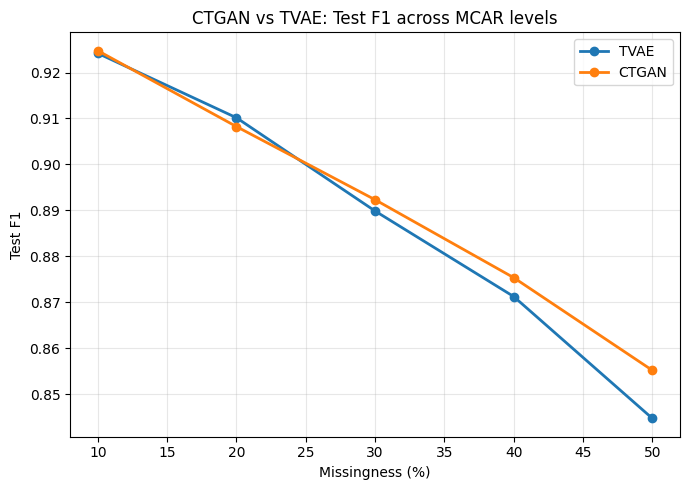

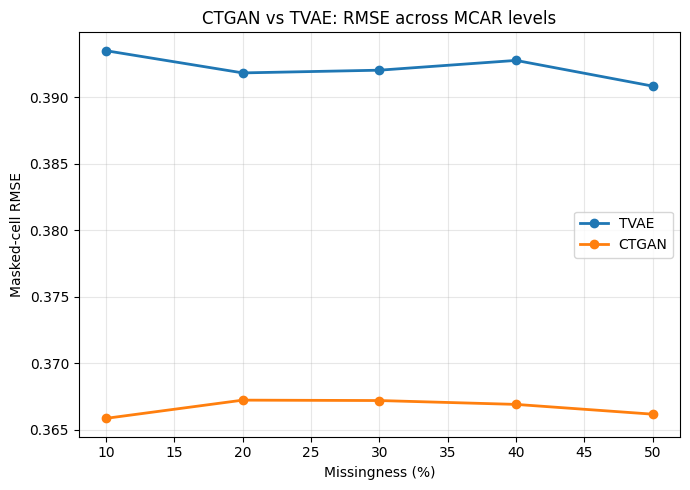

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "/content/drive/MyDrive/research/CTGAN_TVAE_IMPUTE_RESULTS"
AGG_CSV = f"{OUTDIR}/CTGAN_TVAE_AGGREGATED_RESULTS.csv"

df = pd.read_csv(AGG_CSV)

plt.figure(figsize=(7,5))
for model in ["TVAE", "CTGAN"]:
    d = df[df["model"] == model].sort_values("missing_pct")
    plt.plot(d["missing_pct"], d["TestF1_mean"], marker="o", linewidth=2, label=model)

plt.xlabel("Missingness (%)")
plt.ylabel("Test F1")
plt.title("CTGAN vs TVAE: Test F1 across MCAR levels")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))
for model in ["TVAE", "CTGAN"]:
    d = df[df["model"] == model].sort_values("missing_pct")
    plt.plot(d["missing_pct"], d["RMSE_mean"], marker="o", linewidth=2, label=model)

plt.xlabel("Missingness (%)")
plt.ylabel("Masked-cell RMSE")
plt.title("CTGAN vs TVAE: RMSE across MCAR levels")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()